In [1]:
# Imports essentiels seulement
import pandas as pd
import numpy as np
from category_encoders import CatBoostEncoder
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
pd.set_option('display.max_columns', 500)
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from sklearn.model_selection import KFold
import warnings

warnings.filterwarnings("ignore")

In [2]:
#Importation des datasets :
X_train = pd.read_csv("C:/Users/florian/Documents/fac/portfolio/x_train.csv")
y_train = pd.read_csv("C:/Users/florian/Documents/fac/portfolio/y_train.csv")
X_test = pd.read_csv("C:/Users/florian/Documents/fac/portfolio/x_test.csv")

# Afficher un aperçu des données pour vérifier leur chargement
print("Aperçu de X_train :")
display(X_train.head())
print("Aperçu de y_train :")
display(y_train.head())
print("Aperçu de X_test :")
display(X_test.head())

Aperçu de X_train :


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,DUREE_REQANEUF,CARACT4,CARACT5,TYPBAT1,INDEM2,TYPBAT2,FRCH1,FRCH2,DEROG1,DEROG2,DEROG3,DEROG4,DEROG5,DEROG6,DEROG7,DEROG8,DEROG9,DEROG10,DEROG11,DEROG12,DEROG13,DEROG14,DEROG15,DEROG16,TAILLE1,TAILLE2,CA1,CA2,CA3,KAPITAL1,KAPITAL2,KAPITAL3,KAPITAL4,KAPITAL5,KAPITAL6,KAPITAL7,KAPITAL8,KAPITAL9,KAPITAL10,KAPITAL11,KAPITAL12,KAPITAL13,KAPITAL14,KAPITAL15,KAPITAL16,KAPITAL17,KAPITAL18,KAPITAL19,KAPITAL20,KAPITAL21,KAPITAL22,KAPITAL23,KAPITAL24,KAPITAL25,KAPITAL26,KAPITAL27,KAPITAL28,KAPITAL29,KAPITAL30,KAPITAL31,KAPITAL32,KAPITAL33,KAPITAL34,KAPITAL35,KAPITAL36,KAPITAL37,KAPITAL38,KAPITAL39,KAPITAL40,KAPITAL41,KAPITAL42,KAPITAL43,SURFACE1,SURFACE2,SURFACE3,SURFACE4,SURFACE5,SURFACE6,SURFACE7,SURFACE8,SURFACE9,SURFACE10,SURFACE11,SURFACE12,SURFACE13,SURFACE14,SURFACE15,SURFACE16,SURFACE17,SURFACE18,SURFACE19,SURFACE20,SURFACE21,NBBAT1,NBBAT2,NBBAT3,NBBAT4,NBBAT5,NBBAT6,NBBAT7,NBBAT8,NBBAT9,NBBAT10,NBBAT11,NBBAT13,NBBAT14,TAILLE3,TAILLE4,NBSINCONJ,NBSINSTRT,COEFASS,RISK1,RISK2,RISK3,RISK4,RISK5,RISK6,RISK7,RISK8,RISK9,RISK10,RISK11,RISK12,RISK13,EQUIPEMENT1,EQUIPEMENT2,EQUIPEMENT3,EQUIPEMENT4,EQUIPEMENT5,EQUIPEMENT6,EQUIPEMENT7,DISTANCE_111,DISTANCE_112,DISTANCE_121,DISTANCE_122,DISTANCE_123,DISTANCE_124,DISTANCE_131,DISTANCE_132,DISTANCE_133,DISTANCE_141,DISTANCE_142,DISTANCE_211,DISTANCE_212,DISTANCE_213,DISTANCE_221,DISTANCE_222,DISTANCE_223,DISTANCE_231,DISTANCE_242,DISTANCE_243,DISTANCE_244,DISTANCE_311,DISTANCE_312,DISTANCE_313,DISTANCE_321,DISTANCE_322,DISTANCE_323,DISTANCE_324,DISTANCE_331,DISTANCE_332,DISTANCE_333,DISTANCE_334,DISTANCE_335,DISTANCE_411,DISTANCE_412,DISTANCE_421,DISTANCE_422,DISTANCE_423,DISTANCE_511,DISTANCE_512,DISTANCE_521,DISTANCE_522,DISTANCE_523,PROPORTION_11,PROPORTION_12,PROPORTION_13,PROPORTION_14,PROPORTION_21,PROPORTION_22,PROPORTION_23,PROPORTION_24,PROPORTION_31,PROPORTION_32,PROPORTION_33,PROPORTION_41,PROPORTION_42,PROPORTION_51,PROPORTION_52,MEN,MEN_PAUV,MEN_1IND,MEN_5IND,MEN_PROP,MEN_FMP,MEN_COLL,MEN_MAIS,LOG_AVA1,LOG_A1_A2,LOG_A2_A3,LOG_APA3,LOG_INC,LOG_SOC,IND,IND_0_Y1,IND_Y1_Y2,IND_Y2_Y3,IND_Y3_Y4,IND_Y4_Y5,IND_Y5_Y6,IND_Y6_Y7,IND_Y7_Y8,IND_Y8_Y9,IND_Y9,IND_INC,IND_SNV,MEN_SURF,DISTANCE_1,DISTANCE_2,ALTITUDE_1,ALTITUDE_2,ALTITUDE_3,ALTITUDE_4,ALTITUDE_5,BDTOPO_BAT_MAX_HAUTEUR_MAX,HAUTEUR,HAUTEUR_MAX,BDTOPO_BAT_MAX_HAUTEUR,ZONE_VENT,NB_CASERNES,NBJTX25_MM_A,NBJTX25_MMAX_A,NBJTX25_MSOM_A,NBJTX0_MM_A,NBJTX0_MMAX_A,NBJTX0_MSOM_A,NBJTXI27_MM_A,NBJTXI27_MMAX_A,NBJTXI27_MSOM_A,NBJTXS32_MM_A,NBJTXS32_MMAX_A,NBJTXS32_MSOM_A,NBJTXI20_MM_A,NBJTXI20_MMAX_A,NBJTXI20_MSOM_A,NBJTX30_MM_A,NBJTX30_MMAX_A,NBJTX30_MSOM_A,NBJTX35_MM_A,NBJTX35_MMAX_A,NBJTX35_MSOM_A,NBJTN10_MM_A,NBJTN10_MMAX_A,NBJTN10_MSOM_A,NBJTNI10_MM_A,NBJTNI10_MMAX_A,NBJTNI10_MSOM_A,NBJTN5_MM_A,NBJTN5_MMAX_A,NBJTN5_MSOM_A,NBJTNS25_MM_A,NBJTNS25_MMAX_A,NBJTNS25_MSOM_A,NBJTNI15_MM_A,NBJTNI15_MMAX_A,NBJTNI15_MSOM_A,NBJTNI20_MM_A,NBJTNI20_MMAX_A,NBJTNI20_MSOM_A,NBJTNS20_MM_A,NBJTNS20_MMAX_A,NBJTNS20_MSOM_A,NBJTMS24_MM_A,NBJTMS24_MMAX_A,NBJTMS24_MSOM_A,TAMPLIAB_VOR_MM_A,TAMPLIAB_VOR_MMAX_A,TAMPLIM_VOR_MM_A,TAMPLIM_VOR_MMAX_A,TM_VOR_MM_A,TM_VOR_MMAX_A,TMM_VOR_MM_A,TMM_VOR_MMAX_A,TMMAX_VOR_MM_A,TMMAX_VOR_MMAX_A,TMMIN_VOR_MM_A,TMMIN_VOR_MMAX_A,TN_VOR_MM_A,TN_VOR_MMAX_A,TNAB_VOR_MM_A,TNAB_VOR_MMAX_A,TNMAX_VOR_MM_A,TNMAX_VOR_MMAX_A,TX_VOR_MM_A,TX_VOR_MMAX_A,TXAB_VOR_MM_A,TXAB_VOR_MMAX_A,TXMIN_VOR_MM_A,TXMIN_VOR_MMAX_A,NBJFF10_MM_A,NBJFF10_MMAX_A,NBJFF10_MSOM_A,NBJFF16_MM_A,NBJFF16_MMAX_A,NBJFF16_MSOM_A,NBJFF28_MM_A,NBJFF28_MMAX_A,NBJFF28_MSOM_A,NBJFXI3S10_MM_A,NBJFXI3S10_MMAX_A,NBJFXI3S10_MSOM_A,NBJFXI3S16_MM_A,NBJFXI3S16_MMAX_A,NBJFXI3S16_MSOM_A,NBJFXI3S28_MM_A,NBJFXI3S28_MMAX_A,NBJFXI3S28_MSOM_A,NBJFXY8_MM_A,NBJFXY8_MMAX_A,NBJFXY8_MSOM_A,NBJFXY10_MM_A,NBJFXY10_MMAX_A,NBJFXY10_MSOM_A,NBJFXY15_MM_A,NBJFXY15_MMAX_A,NBJFXY15_MSOM_A,FFM_VOR_MM_A,FFM_VOR_MMAX_A,FXI3SAB_VOR_MM_A,FXI3SAB_VOR_MMAX_A,FXIAB_VOR_MM_A,FXIAB_VOR_MMAX_A,FXYAB_VOR_MM_A,FXYAB_VOR_MMAX_A,FFM_VOR_COM_MM_A_Y

Aperçu de y_train :


,ID,FREQ,CM,ANNEE_ASSURANCE,CHARGE
0,1,0.0,0.0,1.000000,0.0
1,2,0.0,0.0,1.000000,0.0
2,3,0.0,0.0,0.402740,0.0
3,4,0.0,0.0,0.246575,0.0
4,5,0.0,0.0,0.838356,0.0


Aperçu de X_test :


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,DUREE_REQANEUF,CARACT4,CARACT5,TYPBAT1,INDEM2,TYPBAT2,FRCH1,FRCH2,DEROG1,DEROG2,DEROG3,DEROG4,DEROG5,DEROG6,DEROG7,DEROG8,DEROG9,DEROG10,DEROG11,DEROG12,DEROG13,DEROG14,DEROG15,DEROG16,TAILLE1,TAILLE2,CA1,CA2,CA3,KAPITAL1,KAPITAL2,KAPITAL3,KAPITAL4,KAPITAL5,KAPITAL6,KAPITAL7,KAPITAL8,KAPITAL9,KAPITAL10,KAPITAL11,KAPITAL12,KAPITAL13,KAPITAL14,KAPITAL15,KAPITAL16,KAPITAL17,KAPITAL18,KAPITAL19,KAPITAL20,KAPITAL21,KAPITAL22,KAPITAL23,KAPITAL24,KAPITAL25,KAPITAL26,KAPITAL27,KAPITAL28,KAPITAL29,KAPITAL30,KAPITAL31,KAPITAL32,KAPITAL33,KAPITAL34,KAPITAL35,KAPITAL36,KAPITAL37,KAPITAL38,KAPITAL39,KAPITAL40,KAPITAL41,KAPITAL42,KAPITAL43,SURFACE1,SURFACE2,SURFACE3,SURFACE4,SURFACE5,SURFACE6,SURFACE7,SURFACE8,SURFACE9,SURFACE10,SURFACE11,SURFACE12,SURFACE13,SURFACE14,SURFACE15,SURFACE16,SURFACE17,SURFACE18,SURFACE19,SURFACE20,SURFACE21,NBBAT1,NBBAT2,NBBAT3,NBBAT4,NBBAT5,NBBAT6,NBBAT7,NBBAT8,NBBAT9,NBBAT10,NBBAT11,NBBAT13,NBBAT14,TAILLE3,TAILLE4,NBSINCONJ,NBSINSTRT,COEFASS,RISK1,RISK2,RISK3,RISK4,RISK5,RISK6,RISK7,RISK8,RISK9,RISK10,RISK11,RISK12,RISK13,EQUIPEMENT1,EQUIPEMENT2,EQUIPEMENT3,EQUIPEMENT4,EQUIPEMENT5,EQUIPEMENT6,EQUIPEMENT7,DISTANCE_111,DISTANCE_112,DISTANCE_121,DISTANCE_122,DISTANCE_123,DISTANCE_124,DISTANCE_131,DISTANCE_132,DISTANCE_133,DISTANCE_141,DISTANCE_142,DISTANCE_211,DISTANCE_212,DISTANCE_213,DISTANCE_221,DISTANCE_222,DISTANCE_223,DISTANCE_231,DISTANCE_242,DISTANCE_243,DISTANCE_244,DISTANCE_311,DISTANCE_312,DISTANCE_313,DISTANCE_321,DISTANCE_322,DISTANCE_323,DISTANCE_324,DISTANCE_331,DISTANCE_332,DISTANCE_333,DISTANCE_334,DISTANCE_335,DISTANCE_411,DISTANCE_412,DISTANCE_421,DISTANCE_422,DISTANCE_423,DISTANCE_511,DISTANCE_512,DISTANCE_521,DISTANCE_522,DISTANCE_523,PROPORTION_11,PROPORTION_12,PROPORTION_13,PROPORTION_14,PROPORTION_21,PROPORTION_22,PROPORTION_23,PROPORTION_24,PROPORTION_31,PROPORTION_32,PROPORTION_33,PROPORTION_41,PROPORTION_42,PROPORTION_51,PROPORTION_52,MEN,MEN_PAUV,MEN_1IND,MEN_5IND,MEN_PROP,MEN_FMP,MEN_COLL,MEN_MAIS,LOG_AVA1,LOG_A1_A2,LOG_A2_A3,LOG_APA3,LOG_INC,LOG_SOC,IND,IND_0_Y1,IND_Y1_Y2,IND_Y2_Y3,IND_Y3_Y4,IND_Y4_Y5,IND_Y5_Y6,IND_Y6_Y7,IND_Y7_Y8,IND_Y8_Y9,IND_Y9,IND_INC,IND_SNV,MEN_SURF,DISTANCE_1,DISTANCE_2,ALTITUDE_1,ALTITUDE_2,ALTITUDE_3,ALTITUDE_4,ALTITUDE_5,BDTOPO_BAT_MAX_HAUTEUR_MAX,HAUTEUR,HAUTEUR_MAX,BDTOPO_BAT_MAX_HAUTEUR,ZONE_VENT,NB_CASERNES,NBJTX25_MM_A,NBJTX25_MMAX_A,NBJTX25_MSOM_A,NBJTX0_MM_A,NBJTX0_MMAX_A,NBJTX0_MSOM_A,NBJTXI27_MM_A,NBJTXI27_MMAX_A,NBJTXI27_MSOM_A,NBJTXS32_MM_A,NBJTXS32_MMAX_A,NBJTXS32_MSOM_A,NBJTXI20_MM_A,NBJTXI20_MMAX_A,NBJTXI20_MSOM_A,NBJTX30_MM_A,NBJTX30_MMAX_A,NBJTX30_MSOM_A,NBJTX35_MM_A,NBJTX35_MMAX_A,NBJTX35_MSOM_A,NBJTN10_MM_A,NBJTN10_MMAX_A,NBJTN10_MSOM_A,NBJTNI10_MM_A,NBJTNI10_MMAX_A,NBJTNI10_MSOM_A,NBJTN5_MM_A,NBJTN5_MMAX_A,NBJTN5_MSOM_A,NBJTNS25_MM_A,NBJTNS25_MMAX_A,NBJTNS25_MSOM_A,NBJTNI15_MM_A,NBJTNI15_MMAX_A,NBJTNI15_MSOM_A,NBJTNI20_MM_A,NBJTNI20_MMAX_A,NBJTNI20_MSOM_A,NBJTNS20_MM_A,NBJTNS20_MMAX_A,NBJTNS20_MSOM_A,NBJTMS24_MM_A,NBJTMS24_MMAX_A,NBJTMS24_MSOM_A,TAMPLIAB_VOR_MM_A,TAMPLIAB_VOR_MMAX_A,TAMPLIM_VOR_MM_A,TAMPLIM_VOR_MMAX_A,TM_VOR_MM_A,TM_VOR_MMAX_A,TMM_VOR_MM_A,TMM_VOR_MMAX_A,TMMAX_VOR_MM_A,TMMAX_VOR_MMAX_A,TMMIN_VOR_MM_A,TMMIN_VOR_MMAX_A,TN_VOR_MM_A,TN_VOR_MMAX_A,TNAB_VOR_MM_A,TNAB_VOR_MMAX_A,TNMAX_VOR_MM_A,TNMAX_VOR_MMAX_A,TX_VOR_MM_A,TX_VOR_MMAX_A,TXAB_VOR_MM_A,TXAB_VOR_MMAX_A,TXMIN_VOR_MM_A,TXMIN_VOR_MMAX_A,NBJFF10_MM_A,NBJFF10_MMAX_A,NBJFF10_MSOM_A,NBJFF16_MM_A,NBJFF16_MMAX_A,NBJFF16_MSOM_A,NBJFF28_MM_A,NBJFF28_MMAX_A,NBJFF28_MSOM_A,NBJFXI3S10_MM_A,NBJFXI3S10_MMAX_A,NBJFXI3S10_MSOM_A,NBJFXI3S16_MM_A,NBJFXI3S16_MMAX_A,NBJFXI3S16_MSOM_A,NBJFXI3S28_MM_A,NBJFXI3S28_MMAX_A,NBJFXI3S28_MSOM_A,NBJFXY8_MM_A,NBJFXY8_MMAX_A,NBJFXY8_MSOM_A,NBJFXY10_MM_A,NBJFXY10_MMAX_A,NBJFXY10_MSOM_A,NBJFXY15_MM_A,NBJFXY15_MMAX_A,NBJFXY15_MSOM_A,FFM_VOR_MM_A,FFM_VOR_MMAX_A,FXI3SAB_VOR_MM_A,FXI3SAB_VOR_MMAX_A,FXIAB_VOR_MM_A,FXIAB_VOR_MMAX_A,FXYAB_VOR_MM_A,FXYAB_VOR_MMAX_A,FFM_VOR_COM_MM_A_Y

In [3]:
# Jointure a gauche des tables  X_train et Y_train on ID:
df = X_train.merge(y_train, on="ID", how="left")

print("Taille :", df.shape)
df.head()

Taille : (383610, 378)


,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,DUREE_REQANEUF,CARACT4,CARACT5,TYPBAT1,INDEM2,TYPBAT2,FRCH1,FRCH2,DEROG1,DEROG2,DEROG3,DEROG4,DEROG5,DEROG6,DEROG7,DEROG8,DEROG9,DEROG10,DEROG11,DEROG12,DEROG13,DEROG14,DEROG15,DEROG16,TAILLE1,TAILLE2,CA1,CA2,CA3,KAPITAL1,KAPITAL2,KAPITAL3,KAPITAL4,KAPITAL5,KAPITAL6,KAPITAL7,KAPITAL8,KAPITAL9,KAPITAL10,KAPITAL11,KAPITAL12,KAPITAL13,KAPITAL14,KAPITAL15,KAPITAL16,KAPITAL17,KAPITAL18,KAPITAL19,KAPITAL20,KAPITAL21,KAPITAL22,KAPITAL23,KAPITAL24,KAPITAL25,KAPITAL26,KAPITAL27,KAPITAL28,KAPITAL29,KAPITAL30,KAPITAL31,KAPITAL32,KAPITAL33,KAPITAL34,KAPITAL35,KAPITAL36,KAPITAL37,KAPITAL38,KAPITAL39,KAPITAL40,KAPITAL41,KAPITAL42,KAPITAL43,SURFACE1,SURFACE2,SURFACE3,SURFACE4,SURFACE5,SURFACE6,SURFACE7,SURFACE8,SURFACE9,SURFACE10,SURFACE11,SURFACE12,SURFACE13,SURFACE14,SURFACE15,SURFACE16,SURFACE17,SURFACE18,SURFACE19,SURFACE20,SURFACE21,NBBAT1,NBBAT2,NBBAT3,NBBAT4,NBBAT5,NBBAT6,NBBAT7,NBBAT8,NBBAT9,NBBAT10,NBBAT11,NBBAT13,NBBAT14,TAILLE3,TAILLE4,NBSINCONJ,NBSINSTRT,COEFASS,RISK1,RISK2,RISK3,RISK4,RISK5,RISK6,RISK7,RISK8,RISK9,RISK10,RISK11,RISK12,RISK13,EQUIPEMENT1,EQUIPEMENT2,EQUIPEMENT3,EQUIPEMENT4,EQUIPEMENT5,EQUIPEMENT6,EQUIPEMENT7,DISTANCE_111,DISTANCE_112,DISTANCE_121,DISTANCE_122,DISTANCE_123,DISTANCE_124,DISTANCE_131,DISTANCE_132,DISTANCE_133,DISTANCE_141,DISTANCE_142,DISTANCE_211,DISTANCE_212,DISTANCE_213,DISTANCE_221,DISTANCE_222,DISTANCE_223,DISTANCE_231,DISTANCE_242,DISTANCE_243,DISTANCE_244,DISTANCE_311,DISTANCE_312,DISTANCE_313,DISTANCE_321,DISTANCE_322,DISTANCE_323,DISTANCE_324,DISTANCE_331,DISTANCE_332,DISTANCE_333,DISTANCE_334,DISTANCE_335,DISTANCE_411,DISTANCE_412,DISTANCE_421,DISTANCE_422,DISTANCE_423,DISTANCE_511,DISTANCE_512,DISTANCE_521,DISTANCE_522,DISTANCE_523,PROPORTION_11,PROPORTION_12,PROPORTION_13,PROPORTION_14,PROPORTION_21,PROPORTION_22,PROPORTION_23,PROPORTION_24,PROPORTION_31,PROPORTION_32,PROPORTION_33,PROPORTION_41,PROPORTION_42,PROPORTION_51,PROPORTION_52,MEN,MEN_PAUV,MEN_1IND,MEN_5IND,MEN_PROP,MEN_FMP,MEN_COLL,MEN_MAIS,LOG_AVA1,LOG_A1_A2,LOG_A2_A3,LOG_APA3,LOG_INC,LOG_SOC,IND,IND_0_Y1,IND_Y1_Y2,IND_Y2_Y3,IND_Y3_Y4,IND_Y4_Y5,IND_Y5_Y6,IND_Y6_Y7,IND_Y7_Y8,IND_Y8_Y9,IND_Y9,IND_INC,IND_SNV,MEN_SURF,DISTANCE_1,DISTANCE_2,ALTITUDE_1,ALTITUDE_2,ALTITUDE_3,ALTITUDE_4,ALTITUDE_5,BDTOPO_BAT_MAX_HAUTEUR_MAX,HAUTEUR,HAUTEUR_MAX,BDTOPO_BAT_MAX_HAUTEUR,ZONE_VENT,NB_CASERNES,NBJTX25_MM_A,NBJTX25_MMAX_A,NBJTX25_MSOM_A,NBJTX0_MM_A,NBJTX0_MMAX_A,NBJTX0_MSOM_A,NBJTXI27_MM_A,NBJTXI27_MMAX_A,NBJTXI27_MSOM_A,NBJTXS32_MM_A,NBJTXS32_MMAX_A,NBJTXS32_MSOM_A,NBJTXI20_MM_A,NBJTXI20_MMAX_A,NBJTXI20_MSOM_A,NBJTX30_MM_A,NBJTX30_MMAX_A,NBJTX30_MSOM_A,NBJTX35_MM_A,NBJTX35_MMAX_A,NBJTX35_MSOM_A,NBJTN10_MM_A,NBJTN10_MMAX_A,NBJTN10_MSOM_A,NBJTNI10_MM_A,NBJTNI10_MMAX_A,NBJTNI10_MSOM_A,NBJTN5_MM_A,NBJTN5_MMAX_A,NBJTN5_MSOM_A,NBJTNS25_MM_A,NBJTNS25_MMAX_A,NBJTNS25_MSOM_A,NBJTNI15_MM_A,NBJTNI15_MMAX_A,NBJTNI15_MSOM_A,NBJTNI20_MM_A,NBJTNI20_MMAX_A,NBJTNI20_MSOM_A,NBJTNS20_MM_A,NBJTNS20_MMAX_A,NBJTNS20_MSOM_A,NBJTMS24_MM_A,NBJTMS24_MMAX_A,NBJTMS24_MSOM_A,TAMPLIAB_VOR_MM_A,TAMPLIAB_VOR_MMAX_A,TAMPLIM_VOR_MM_A,TAMPLIM_VOR_MMAX_A,TM_VOR_MM_A,TM_VOR_MMAX_A,TMM_VOR_MM_A,TMM_VOR_MMAX_A,TMMAX_VOR_MM_A,TMMAX_VOR_MMAX_A,TMMIN_VOR_MM_A,TMMIN_VOR_MMAX_A,TN_VOR_MM_A,TN_VOR_MMAX_A,TNAB_VOR_MM_A,TNAB_VOR_MMAX_A,TNMAX_VOR_MM_A,TNMAX_VOR_MMAX_A,TX_VOR_MM_A,TX_VOR_MMAX_A,TXAB_VOR_MM_A,TXAB_VOR_MMAX_A,TXMIN_VOR_MM_A,TXMIN_VOR_MMAX_A,NBJFF10_MM_A,NBJFF10_MMAX_A,NBJFF10_MSOM_A,NBJFF16_MM_A,NBJFF16_MMAX_A,NBJFF16_MSOM_A,NBJFF28_MM_A,NBJFF28_MMAX_A,NBJFF28_MSOM_A,NBJFXI3S10_MM_A,NBJFXI3S10_MMAX_A,NBJFXI3S10_MSOM_A,NBJFXI3S16_MM_A,NBJFXI3S16_MMAX_A,NBJFXI3S16_MSOM_A,NBJFXI3S28_MM_A,NBJFXI3S28_MMAX_A,NBJFXI3S28_MSOM_A,NBJFXY8_MM_A,NBJFXY8_MMAX_A,NBJFXY8_MSOM_A,NBJFXY10_MM_A,NBJFXY10_MMAX_A,NBJFXY10_MSOM_A,NBJFXY15_MM_A,NBJFXY15_MMAX_A,NBJFXY15_MSOM_A,FFM_VOR_MM_A,FFM_VOR_MMAX_A,FXI3SAB_VOR_MM_A,FXI3SAB_VOR_MMAX_A,FXIAB_VOR_MM_A,FXIAB_VOR_MMAX_A,FXYAB_VOR_MM_A,FXYAB_VOR_MMAX_A,FFM_VOR_COM_MM_A_Y

In [4]:
#On supprime la colonne anne_assurance qui a été dupliquée 
df = df.drop(columns=["ANNEE_ASSURANCE_y"], errors="ignore") 
df = df.rename(columns={"ANNEE_ASSURANCE_x": "ANNEE_ASSURANCE"})
df.head()

,ID,ACTIVIT2,VOCATION,TYPERS,ANCIENNETE,ADOSS,CARACT1,CARACT2,CARACT3,INDEM1,DUREE_REQANEUF,CARACT4,CARACT5,TYPBAT1,INDEM2,TYPBAT2,FRCH1,FRCH2,DEROG1,DEROG2,DEROG3,DEROG4,DEROG5,DEROG6,DEROG7,DEROG8,DEROG9,DEROG10,DEROG11,DEROG12,DEROG13,DEROG14,DEROG15,DEROG16,TAILLE1,TAILLE2,CA1,CA2,CA3,KAPITAL1,KAPITAL2,KAPITAL3,KAPITAL4,KAPITAL5,KAPITAL6,KAPITAL7,KAPITAL8,KAPITAL9,KAPITAL10,KAPITAL11,KAPITAL12,KAPITAL13,KAPITAL14,KAPITAL15,KAPITAL16,KAPITAL17,KAPITAL18,KAPITAL19,KAPITAL20,KAPITAL21,KAPITAL22,KAPITAL23,KAPITAL24,KAPITAL25,KAPITAL26,KAPITAL27,KAPITAL28,KAPITAL29,KAPITAL30,KAPITAL31,KAPITAL32,KAPITAL33,KAPITAL34,KAPITAL35,KAPITAL36,KAPITAL37,KAPITAL38,KAPITAL39,KAPITAL40,KAPITAL41,KAPITAL42,KAPITAL43,SURFACE1,SURFACE2,SURFACE3,SURFACE4,SURFACE5,SURFACE6,SURFACE7,SURFACE8,SURFACE9,SURFACE10,SURFACE11,SURFACE12,SURFACE13,SURFACE14,SURFACE15,SURFACE16,SURFACE17,SURFACE18,SURFACE19,SURFACE20,SURFACE21,NBBAT1,NBBAT2,NBBAT3,NBBAT4,NBBAT5,NBBAT6,NBBAT7,NBBAT8,NBBAT9,NBBAT10,NBBAT11,NBBAT13,NBBAT14,TAILLE3,TAILLE4,NBSINCONJ,NBSINSTRT,COEFASS,RISK1,RISK2,RISK3,RISK4,RISK5,RISK6,RISK7,RISK8,RISK9,RISK10,RISK11,RISK12,RISK13,EQUIPEMENT1,EQUIPEMENT2,EQUIPEMENT3,EQUIPEMENT4,EQUIPEMENT5,EQUIPEMENT6,EQUIPEMENT7,DISTANCE_111,DISTANCE_112,DISTANCE_121,DISTANCE_122,DISTANCE_123,DISTANCE_124,DISTANCE_131,DISTANCE_132,DISTANCE_133,DISTANCE_141,DISTANCE_142,DISTANCE_211,DISTANCE_212,DISTANCE_213,DISTANCE_221,DISTANCE_222,DISTANCE_223,DISTANCE_231,DISTANCE_242,DISTANCE_243,DISTANCE_244,DISTANCE_311,DISTANCE_312,DISTANCE_313,DISTANCE_321,DISTANCE_322,DISTANCE_323,DISTANCE_324,DISTANCE_331,DISTANCE_332,DISTANCE_333,DISTANCE_334,DISTANCE_335,DISTANCE_411,DISTANCE_412,DISTANCE_421,DISTANCE_422,DISTANCE_423,DISTANCE_511,DISTANCE_512,DISTANCE_521,DISTANCE_522,DISTANCE_523,PROPORTION_11,PROPORTION_12,PROPORTION_13,PROPORTION_14,PROPORTION_21,PROPORTION_22,PROPORTION_23,PROPORTION_24,PROPORTION_31,PROPORTION_32,PROPORTION_33,PROPORTION_41,PROPORTION_42,PROPORTION_51,PROPORTION_52,MEN,MEN_PAUV,MEN_1IND,MEN_5IND,MEN_PROP,MEN_FMP,MEN_COLL,MEN_MAIS,LOG_AVA1,LOG_A1_A2,LOG_A2_A3,LOG_APA3,LOG_INC,LOG_SOC,IND,IND_0_Y1,IND_Y1_Y2,IND_Y2_Y3,IND_Y3_Y4,IND_Y4_Y5,IND_Y5_Y6,IND_Y6_Y7,IND_Y7_Y8,IND_Y8_Y9,IND_Y9,IND_INC,IND_SNV,MEN_SURF,DISTANCE_1,DISTANCE_2,ALTITUDE_1,ALTITUDE_2,ALTITUDE_3,ALTITUDE_4,ALTITUDE_5,BDTOPO_BAT_MAX_HAUTEUR_MAX,HAUTEUR,HAUTEUR_MAX,BDTOPO_BAT_MAX_HAUTEUR,ZONE_VENT,NB_CASERNES,NBJTX25_MM_A,NBJTX25_MMAX_A,NBJTX25_MSOM_A,NBJTX0_MM_A,NBJTX0_MMAX_A,NBJTX0_MSOM_A,NBJTXI27_MM_A,NBJTXI27_MMAX_A,NBJTXI27_MSOM_A,NBJTXS32_MM_A,NBJTXS32_MMAX_A,NBJTXS32_MSOM_A,NBJTXI20_MM_A,NBJTXI20_MMAX_A,NBJTXI20_MSOM_A,NBJTX30_MM_A,NBJTX30_MMAX_A,NBJTX30_MSOM_A,NBJTX35_MM_A,NBJTX35_MMAX_A,NBJTX35_MSOM_A,NBJTN10_MM_A,NBJTN10_MMAX_A,NBJTN10_MSOM_A,NBJTNI10_MM_A,NBJTNI10_MMAX_A,NBJTNI10_MSOM_A,NBJTN5_MM_A,NBJTN5_MMAX_A,NBJTN5_MSOM_A,NBJTNS25_MM_A,NBJTNS25_MMAX_A,NBJTNS25_MSOM_A,NBJTNI15_MM_A,NBJTNI15_MMAX_A,NBJTNI15_MSOM_A,NBJTNI20_MM_A,NBJTNI20_MMAX_A,NBJTNI20_MSOM_A,NBJTNS20_MM_A,NBJTNS20_MMAX_A,NBJTNS20_MSOM_A,NBJTMS24_MM_A,NBJTMS24_MMAX_A,NBJTMS24_MSOM_A,TAMPLIAB_VOR_MM_A,TAMPLIAB_VOR_MMAX_A,TAMPLIM_VOR_MM_A,TAMPLIM_VOR_MMAX_A,TM_VOR_MM_A,TM_VOR_MMAX_A,TMM_VOR_MM_A,TMM_VOR_MMAX_A,TMMAX_VOR_MM_A,TMMAX_VOR_MMAX_A,TMMIN_VOR_MM_A,TMMIN_VOR_MMAX_A,TN_VOR_MM_A,TN_VOR_MMAX_A,TNAB_VOR_MM_A,TNAB_VOR_MMAX_A,TNMAX_VOR_MM_A,TNMAX_VOR_MMAX_A,TX_VOR_MM_A,TX_VOR_MMAX_A,TXAB_VOR_MM_A,TXAB_VOR_MMAX_A,TXMIN_VOR_MM_A,TXMIN_VOR_MMAX_A,NBJFF10_MM_A,NBJFF10_MMAX_A,NBJFF10_MSOM_A,NBJFF16_MM_A,NBJFF16_MMAX_A,NBJFF16_MSOM_A,NBJFF28_MM_A,NBJFF28_MMAX_A,NBJFF28_MSOM_A,NBJFXI3S10_MM_A,NBJFXI3S10_MMAX_A,NBJFXI3S10_MSOM_A,NBJFXI3S16_MM_A,NBJFXI3S16_MMAX_A,NBJFXI3S16_MSOM_A,NBJFXI3S28_MM_A,NBJFXI3S28_MMAX_A,NBJFXI3S28_MSOM_A,NBJFXY8_MM_A,NBJFXY8_MMAX_A,NBJFXY8_MSOM_A,NBJFXY10_MM_A,NBJFXY10_MMAX_A,NBJFXY10_MSOM_A,NBJFXY15_MM_A,NBJFXY15_MMAX_A,NBJFXY15_MSOM_A,FFM_VOR_MM_A,FFM_VOR_MMAX_A,FXI3SAB_VOR_MM_A,FXI3SAB_VOR_MMAX_A,FXIAB_VOR_MM_A,FXIAB_VOR_MMAX_A,FXYAB_VOR_MM_A,FXYAB_VOR_MMAX_A,FFM_VOR_COM_MM_A_Y

In [5]:
# Informations générales
df.info()

# Pourcentage de valeurs manquantes
missing = df.isna().mean().sort_values(ascending=False)
print("Top colonnes avec NaN :")
print(missing.head(20))

# Suppression des colonnes trop manquantes
cols_to_drop = missing[missing > 0.90].index.tolist()

print("\nColonnes supprimées (NaN > 90%) :")
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)
print("\nNouveau nombre de colonnes :", df.shape[1])

X_test = X_test.drop(columns=cols_to_drop, errors="ignore")

<class 'pandas.DataFrame'>
RangeIndex: 383610 entries, 0 to 383609
Columns: 377 entries, ID to CHARGE
dtypes: float64(39), int64(58), object(1), str(279)
memory usage: 1.5+ GB
Top colonnes avec NaN :
DEROG14                       0.999979
DEROG13                       0.996629
DEROG16                       0.991523
CARACT2                       0.960048
CARACT3                       0.960048
TYPBAT1                       0.921081
DEROG12                       0.909981
BDTOPO_BAT_MAX_HAUTEUR        0.618819
HAUTEUR_MAX                   0.618819
HAUTEUR                       0.618819
BDTOPO_BAT_MAX_HAUTEUR_MAX    0.618819
DISTANCE_311                  0.572798
DISTANCE_313                  0.570650
DISTANCE_312                  0.570350
DISTANCE_324                  0.570267
DISTANCE_2                    0.570003
DISTANCE_244                  0.569824
TMM_VOR_MM_A                  0.567535
FFM_VOR_MMAX_A                0.567535
FFM_VOR_MM_A                  0.567535
dtype: float64

Colo

In [6]:
#Séparations des variables:

#Variables numériques 
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()

#Variables catégorielles 
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# On enlève les cibles pour les listes de features
for col in ["FREQ", "CM", "CHARGE"]:
    if col in num_cols: num_cols.remove(col)
    if col in cat_cols: cat_cols.remove(col)

print("Nb colonnes numériques :", len(num_cols))
print("Nb colonnes catégorielles :", len(cat_cols))

Nb colonnes numériques : 93
Nb colonnes catégorielles : 274


In [7]:
# Imputation des NaN

#df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[num_cols] = df[num_cols].fillna(0)
df[cat_cols] = df[cat_cols].fillna("MISSING")

In [8]:
# On sélectionne UNIQUEMENT les colonnes numériques contenant "surface"
surface_cols = [c for c in num_cols if "surface" in c.lower()]
df["surface_totale"] = df[surface_cols].sum(axis=1)


# Capital total
capital_cols = [c for c in num_cols if "kapital" in c.lower()]
df["capital_total"] = df[capital_cols].sum(axis=1)


# Ratio
df["ratio_capital_surface"] = df["capital_total"] / (df["surface_totale"] + 1)


# Taux sinistres passés
df["taux_sinistres_passes"] = df["NBSINCONJ"] / (df["ANNEE_ASSURANCE"] + 1)

In [9]:
# On met à jour num_cols pour inclure les nouvelles features
num_cols = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
for col in ["FREQ", "CM", "CHARGE"]:
    if col in num_cols: num_cols.remove(col)

# CHARGE = FREQ * CM * ANNEE_ASSURANCE
df["CHARGE"] = df["FREQ"] * df["CM"] * df["ANNEE_ASSURANCE"]

# Identification des colonnes object (catégorielles)
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Encodage
encoder = CatBoostEncoder(cols=cat_cols, random_state=42)
df_enc = df.copy()
df_enc[cat_cols] = encoder.fit_transform(df[cat_cols], df["CHARGE"])

In [10]:
# Suppression de l'ID
df_clean = df_enc.drop(columns=["ID"])

# Dataset pour FREQ 
df_freq = df_clean.drop(columns=["CM", "CHARGE"])

# Dataset pour CM (uniquement sinistres > 0)
df_cm = df_clean[df_clean["CM"] > 0].drop(columns=["FREQ", "CHARGE"])

In [11]:
# Séparation FREQ 
X_freq = df_freq.drop(columns=["FREQ"])

y_freq = df_freq["FREQ"]

# Séparation CM 
X_cm_full = df_cm.drop(columns=["CM"])
y_cm_full = df_cm["CM"]

print("Dimensions :")
print("X_freq :", X_freq.shape, " | y_freq :", y_freq.shape)
print("X_cm   :", X_cm_full.shape,   " | y_cm   :", y_cm_full.shape)

Dimensions :
X_freq : (383610, 370)  | y_freq : (383610,)
X_cm   : (2352, 370)  | y_cm   : (2352,)


Résumé statistique FREQ :
count    383610.000000
mean          0.012452
std           0.357127
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         182.499998
Name: FREQ, dtype: float64


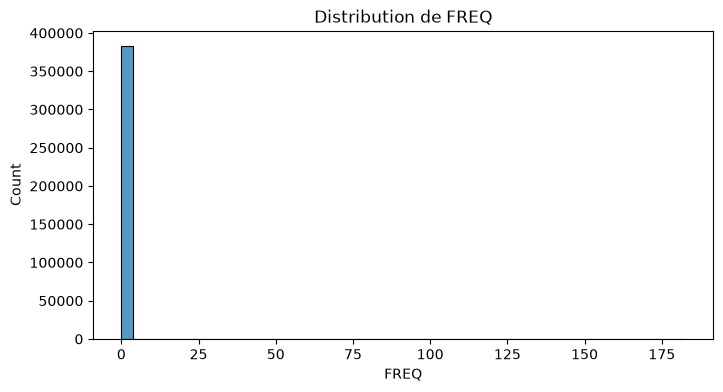


Résumé statistique CM :
count      2352.000000
mean      29775.080531
std       80268.512708
min           1.000000
25%         489.187500
50%        1786.600000
75%       10005.050000
max      500000.000000
Name: CM, dtype: float64


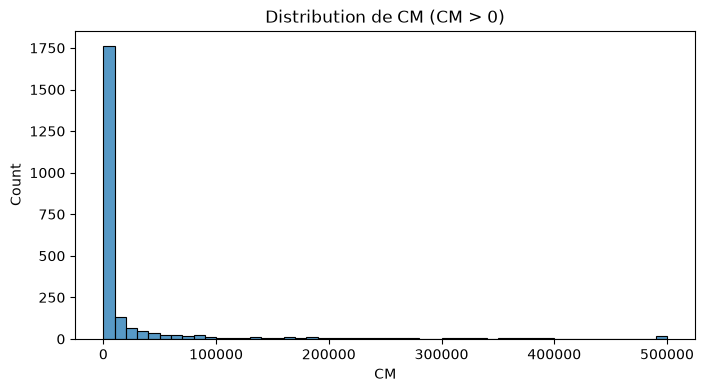

In [12]:
# Analyse FREQ 
print("Résumé statistique FREQ :")
print(y_freq.describe())

plt.figure(figsize=(8,4))
sns.histplot(y_freq, bins=50, kde=False)
plt.title("Distribution de FREQ")
plt.show()


# Analyse CM 
print("\nRésumé statistique CM :")
print(y_cm_full.describe())

plt.figure(figsize=(8,4))
sns.histplot(y_cm_full, bins=50, kde=False)
plt.title("Distribution de CM (CM > 0)")
plt.show()

In [13]:
# Petite grille d'hyperparamètres pour FREQ
depth_list = [8]
iterations_list = [400, 800]
learning_rate_list = [0.03, 0.05]
l2_list = [3, 8]

results_freq = []

kf = KFold(n_splits=2, shuffle=True, random_state=42)

for depth, iters, lr, l2 in product(depth_list, iterations_list, learning_rate_list, l2_list):
    preds_oof = np.zeros(len(X_freq))  # prédictions "out-of-fold"
    
    for train_idx, val_idx in kf.split(X_freq):
        model = CatBoostRegressor(
            iterations=iters,
            depth=depth,
            learning_rate=lr,
            bagging_temperature=1,
            l2_leaf_reg=l2,
            loss_function="RMSE",
            random_seed=42,
            verbose=False
        )
        
        model.fit(X_freq.iloc[train_idx], y_freq.iloc[train_idx])
        preds_oof[val_idx] = model.predict(X_freq.iloc[val_idx])
    
    rmse = np.sqrt(mean_squared_error(y_freq, preds_oof))
    results_freq.append({
        "depth": depth,
        "iterations": iters,
        "learning_rate": lr,
        "l2_leaf_reg": l2,
        "rmse": rmse
    })
    print(f"depth={depth}, iters={iters}, lr={lr}, l2={l2}  -> RMSE={rmse:.6f}")

# On trie les résultats par RMSE croissant
results_freq_sorted = sorted(results_freq, key=lambda x: x["rmse"])
best_freq = results_freq_sorted[0]

print("\nMeilleure config FREQ trouvée :")
print(best_freq)

depth=8, iters=400, lr=0.03, l2=3  -> RMSE=0.357586
depth=8, iters=400, lr=0.03, l2=8  -> RMSE=0.357618
depth=8, iters=400, lr=0.05, l2=3  -> RMSE=0.358181
depth=8, iters=400, lr=0.05, l2=8  -> RMSE=0.357851
depth=8, iters=800, lr=0.03, l2=3  -> RMSE=0.358022
depth=8, iters=800, lr=0.03, l2=8  -> RMSE=0.357953
depth=8, iters=800, lr=0.05, l2=3  -> RMSE=0.359035
depth=8, iters=800, lr=0.05, l2=8  -> RMSE=0.358441

Meilleure config FREQ trouvée :
{'depth': 8, 'iterations': 400, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'rmse': np.float64(0.3575860654294599)}


In [14]:
# Petite grille d'hyperparamètres pour CM
depth_list = [4, 6]               # profondeur des arbres
iterations_list = [400, 600]      # nombre d'itérations
learning_rate_list = [0.03, 0.04] # taux d'apprentissage
l2_list = [5, 10]                 # régularisation L2

results_cm = []

kf = KFold(n_splits=2, shuffle=True, random_state=42)

for depth, iters, lr, l2 in product(depth_list, iterations_list, learning_rate_list, l2_list):
    preds_oof = np.zeros(len(X_cm_full))  # prédictions out-of-fold
    
    for train_idx, val_idx in kf.split(X_cm_full):
        model = CatBoostRegressor(
            iterations=iters,
            depth=depth,
            learning_rate=lr,
            bagging_temperature=1,
            l2_leaf_reg=l2,
            loss_function="RMSE",
            random_seed=42,
            verbose=False
        )
        
        model.fit(X_cm_full.iloc[train_idx], y_cm_full.iloc[train_idx])
        preds_oof[val_idx] = model.predict(X_cm_full.iloc[val_idx])
    
    rmse = np.sqrt(mean_squared_error(y_cm_full, preds_oof))
    results_cm.append({
        "depth": depth,
        "iterations": iters,
        "learning_rate": lr,
        "l2_leaf_reg": l2,
        "rmse": rmse
    })
    print(f"CM | depth={depth}, iters={iters}, lr={lr}, l2={l2}  -> RMSE={rmse:.6f}")

# On trie par RMSE croissant
results_cm_sorted = sorted(results_cm, key=lambda x: x["rmse"])
best_cm = results_cm_sorted[0]

print("\nMeilleure config CM trouvée :")
print(best_cm)

CM | depth=4, iters=400, lr=0.03, l2=5  -> RMSE=79905.713396
CM | depth=4, iters=400, lr=0.03, l2=10  -> RMSE=79859.669601
CM | depth=4, iters=400, lr=0.04, l2=5  -> RMSE=80269.696892
CM | depth=4, iters=400, lr=0.04, l2=10  -> RMSE=79945.653321
CM | depth=4, iters=600, lr=0.03, l2=5  -> RMSE=80378.702551
CM | depth=4, iters=600, lr=0.03, l2=10  -> RMSE=80181.981051
CM | depth=4, iters=600, lr=0.04, l2=5  -> RMSE=81111.713336
CM | depth=4, iters=600, lr=0.04, l2=10  -> RMSE=80371.049045
CM | depth=6, iters=400, lr=0.03, l2=5  -> RMSE=79588.685961
CM | depth=6, iters=400, lr=0.03, l2=10  -> RMSE=79536.641722
CM | depth=6, iters=400, lr=0.04, l2=5  -> RMSE=80091.529243
CM | depth=6, iters=400, lr=0.04, l2=10  -> RMSE=79728.213859
CM | depth=6, iters=600, lr=0.03, l2=5  -> RMSE=79959.792500
CM | depth=6, iters=600, lr=0.03, l2=10  -> RMSE=79677.438210
CM | depth=6, iters=600, lr=0.04, l2=5  -> RMSE=80614.518389
CM | depth=6, iters=600, lr=0.04, l2=10  -> RMSE=80034.886299

Meilleure confi

In [15]:
model_CB_freq = CatBoostRegressor(
    iterations=best_freq["iterations"],
    depth=best_freq["depth"],
    learning_rate=best_freq["learning_rate"],
    bagging_temperature=1,
    l2_leaf_reg=best_freq["l2_leaf_reg"],
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

model_CB_freq.fit(X_freq, y_freq)

CatBoostRegressor(bagging_temperature=1, depth=8, iterations=400, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)

In [16]:
model_CB_cm = CatBoostRegressor(
    iterations=best_cm["iterations"],
    depth=best_cm["depth"],
    learning_rate=best_cm["learning_rate"],
    bagging_temperature=1,
    l2_leaf_reg=best_cm["l2_leaf_reg"],
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)
model_CB_cm.fit(X_cm_full, y_cm_full)

CatBoostRegressor(bagging_temperature=1, depth=6, iterations=400, l2_leaf_reg=10, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=False)

In [17]:
# 1) Prédiction de la fréquence 
pred_freq_train = model_CB_freq.predict(X_freq)

# 2) Prédiction du coût moyen
pred_cm_train_raw = model_CB_cm.predict(X_cm_full)   # seulement CM > 0
pred_cm_train_full = np.zeros(df_clean.shape[0])     # même  les CM = 0 
pred_cm_train_full[df_cm.index] = pred_cm_train_raw  

# 4)  Prédiction de la vraie CHARGE 
annee_train = df_freq["ANNEE_ASSURANCE"].values      # ancienneté contrat
y_charge = df_enc["CHARGE"].values                   # vraie charge

pred_charge_cat_train = pred_freq_train * pred_cm_train_full * annee_train

# 5) RMSE CatBoost sur la charge
rmse_cat_train = np.sqrt(mean_squared_error(y_charge, pred_charge_cat_train))
print("RMSE train CatBoost (FREQ×CM×ANNEE) :", rmse_cat_train)

RMSE train CatBoost (FREQ×CM×ANNEE) : 6750.186293942117


In [18]:
# ==============================
# 13.1. Données pour HGBR (CHARGE directe)

X_charge = df_enc.drop(columns=["ID", "FREQ", "CM", "CHARGE"])
y_charge = df_enc["CHARGE"].values

print("Shape X_charge :", X_charge.shape, "| y_charge :", y_charge.shape)

# ==============================
# 13.2. Recherche d'hyperparamètres HGBR (CV 5-fold)
# ==============================
max_iter_list = [300, 400, 600]
learning_rate_list = [0.03, 0.05]
max_leaf_nodes_list = [31, 63, 127]
l2_list = [0.0, 1.0, 5.0]

results_hgbr = []

kf = KFold(n_splits=2, shuffle=True, random_state=42)

for max_iter, lr, max_leaf, l2 in product(
    max_iter_list, learning_rate_list, max_leaf_nodes_list, l2_list
):
    preds_oof = np.zeros(len(X_charge))  # prédictions out-of-fold
    
    for train_idx, val_idx in kf.split(X_charge):
        model = HistGradientBoostingRegressor(
            max_iter=max_iter,
            learning_rate=lr,
            max_leaf_nodes=max_leaf,
            l2_regularization=l2,
            random_state=42
        )
        
        model.fit(X_charge.iloc[train_idx], y_charge[train_idx])
        preds_oof[val_idx] = model.predict(X_charge.iloc[val_idx])
    
    rmse = np.sqrt(mean_squared_error(y_charge, preds_oof))
    results_hgbr.append({
        "max_iter": max_iter,
        "learning_rate": lr,
        "max_leaf_nodes": max_leaf,
        "l2_regularization": l2,
        "rmse": rmse
    })
    print(f"HGBR | max_iter={max_iter}, lr={lr}, max_leaf={max_leaf}, l2={l2} -> RMSE={rmse:.6f}")

# Tri des résultats par RMSE croissant
results_hgbr_sorted = sorted(results_hgbr, key=lambda x: x["rmse"])
best_hgbr = results_hgbr_sorted[0]

print("\nMeilleure config HGBR trouvée :")
print(best_hgbr)

Shape X_charge : (383610, 370) | y_charge : (383610,)
HGBR | max_iter=300, lr=0.03, max_leaf=31, l2=0.0 -> RMSE=6800.466506
HGBR | max_iter=300, lr=0.03, max_leaf=31, l2=1.0 -> RMSE=6800.304184
HGBR | max_iter=300, lr=0.03, max_leaf=31, l2=5.0 -> RMSE=6800.226859
HGBR | max_iter=300, lr=0.03, max_leaf=63, l2=0.0 -> RMSE=6801.994758
HGBR | max_iter=300, lr=0.03, max_leaf=63, l2=1.0 -> RMSE=6801.612915
HGBR | max_iter=300, lr=0.03, max_leaf=63, l2=5.0 -> RMSE=6802.578843
HGBR | max_iter=300, lr=0.03, max_leaf=127, l2=0.0 -> RMSE=6803.796509
HGBR | max_iter=300, lr=0.03, max_leaf=127, l2=1.0 -> RMSE=6802.556746
HGBR | max_iter=300, lr=0.03, max_leaf=127, l2=5.0 -> RMSE=6801.992729
HGBR | max_iter=300, lr=0.05, max_leaf=31, l2=0.0 -> RMSE=6804.482246
HGBR | max_iter=300, lr=0.05, max_leaf=31, l2=1.0 -> RMSE=6806.630954
HGBR | max_iter=300, lr=0.05, max_leaf=31, l2=5.0 -> RMSE=6803.249534
HGBR | max_iter=300, lr=0.05, max_leaf=63, l2=0.0 -> RMSE=6807.055056
HGBR | max_iter=300, lr=0.05, max

In [19]:
hgbr = HistGradientBoostingRegressor(
    max_iter=best_hgbr["max_iter"],
    learning_rate=best_hgbr["learning_rate"],
    max_leaf_nodes=best_hgbr["max_leaf_nodes"],
    l2_regularization=best_hgbr["l2_regularization"],
    random_state=42
)
hgbr.fit(X_charge, y_charge)

pred_charge_hgbr_train = hgbr.predict(X_charge)
rmse_hgbr_train = np.sqrt(mean_squared_error(y_charge, pred_charge_hgbr_train))
print("RMSE train HGBR (CHARGE directe) :", rmse_hgbr_train)

RMSE train HGBR (CHARGE directe) : 6756.545067949349


In [20]:
# Alpha gagnant déterminé par les essais / leaderboard
best_alpha = 0.3  # à ajuster si ton alpha optimal est légèrement différent

# Combinaison linéaire des deux modèles sur le train
pred_charge_ens_train = (
    best_alpha * pred_charge_cat_train
    + (1 - best_alpha) * pred_charge_hgbr_train
)

rmse_ens_train = np.sqrt(mean_squared_error(y_charge, pred_charge_ens_train))
print(f"RMSE ensemble train (alpha={best_alpha:.1f}) = {rmse_ens_train:.6f}")

RMSE ensemble train (alpha=0.3) = 6753.679537


In [21]:
rmse_methods = {
    "catboost": rmse_cat_train,
    "hgbr": rmse_hgbr_train,
    "ensemble": rmse_ens_train   # plus de [best_alpha] ici
}

best_method = min(rmse_methods, key=rmse_methods.get)
print("Méthode sélectionnée :", best_method, "avec RMSE =", rmse_methods[best_method])

Méthode sélectionnée : catboost avec RMSE = 6750.186293942117


In [22]:
# ============================================
# PIPELINE TEST 100% COHÉRENT AVEC LE TRAIN
# ============================================

test = X_test.copy()

# 1. Suppression des mêmes colonnes qu'au train
test = test.drop(columns=cols_to_drop, errors="ignore")

# 2. Imputation identique
num_cols_test = [c for c in num_cols if c in test.columns]
cat_cols_test = [c for c in cat_cols if c in test.columns]

test[num_cols_test] = test[num_cols_test].fillna(0)
test[cat_cols_test] = test[cat_cols_test].fillna("MISSING")

# 3. Feature engineering identique
# (sécurisé : ignore les colonnes absentes)
test["surface_totale"] = test[[c for c in surface_cols if c in test.columns]].sum(axis=1)
test["capital_total"]  = test[[c for c in capital_cols if c in test.columns]].sum(axis=1)

test["ratio_capital_surface"] = test["capital_total"] / (test["surface_totale"] + 1)
test["taux_sinistres_passes"] = test["NBSINCONJ"] / (test["ANNEE_ASSURANCE"] + 1)

# 4. Encodage CatBoostEncoder (même colonnes qu'au train)
test_encoded = test.copy()
test_encoded[cat_cols] = encoder.transform(test[cat_cols])

# 5. Suppression ID comme dans df_clean
if "ID" in test_encoded.columns:
    test_encoded = test_encoded.drop(columns=["ID"])

print("Shape test_encoded :", test_encoded.shape)

Shape test_encoded : (95852, 370)


In [23]:
# ==============================
# 2. PRÉDICTION TEST CATBOOST (FREQ / CM)
# ==============================

# 2.1 — Prédiction FREQ
pred_freq_test = model_CB_freq.predict(test_encoded[X_freq.columns])

# 2.2 — Prédiction CM brute
pred_cm_raw_test = model_CB_cm.predict(test_encoded[X_cm_full.columns])

# 2.3 — CM = 0 si FREQ quasi nulle
pred_cm_test = np.where(pred_freq_test > 1e-4, pred_cm_raw_test, 0)

# 2.4 — CHARGE CatBoost = FREQ × CM × ANNEE_ASSURANCE
annee_test = test["ANNEE_ASSURANCE"].values

pred_charge_cat_test = pred_freq_test * pred_cm_test * annee_test
pred_charge_cat_test = np.maximum(pred_charge_cat_test, 0)   # aucune valeur négative

print("\nRésumé CHARGE test CatBoost :")
print(pd.Series(pred_charge_cat_test).describe())


Résumé CHARGE test CatBoost :
count    95852.000000
mean       207.482273
std        289.682731
min          0.000000
25%         35.377759
50%         96.183536
75%        259.803872
max       8678.057160
dtype: float64


In [24]:
# ==============================
# 3. PRÉDICTION TEST HGBR (CHARGE DIRECTE)
# ==============================

# même ordre de colonnes que X_charge du train
X_test_charge = test_encoded[X_charge.columns]

pred_charge_hgbr_test = hgbr.predict(X_test_charge)
pred_charge_hgbr_test = np.maximum(pred_charge_hgbr_test, 0)

print("\nRésumé CHARGE HGBR test :")
print(pd.Series(pred_charge_hgbr_test).describe())


Résumé CHARGE HGBR test :
count    95852.000000
mean       184.903577
std         92.526087
min          7.011667
25%        166.976618
50%        166.976618
75%        171.692174
max       4580.565580
dtype: float64


In [25]:
# ==============================
# 4. PRÉDICTION TEST ENSEMBLE (MODÈLE FINAL)
# ==============================

best_alpha = 0.3   # alpha optimal identifié pendant le train

pred_charge_ens_test = (
    best_alpha * pred_charge_cat_test
    + (1 - best_alpha) * pred_charge_hgbr_test
)

# Pas de négatifs
pred_charge_ens_test = np.maximum(pred_charge_ens_test, 0)

print("\nRésumé CHARGE ensemble test (clippé >= 0) :")
print(pd.Series(pred_charge_ens_test).describe())


Résumé CHARGE ensemble test (clippé >= 0) :
count    95852.000000
mean       191.677185
std        127.832025
min        116.883632
25%        127.953922
50%        147.425687
75%        201.649776
max       3795.297003
dtype: float64


In [26]:
# ==============================
# 5. SOUMISSION FINALE ENSEMBLE
# ==============================

submission_ensemble_final_mercredi = pd.DataFrame({
    "ID": X_test["ID"],
    "CHARGE": pred_charge_ens_test
})

submission_ensemble_final_mercredi.to_csv(
    "submission_ensemble_final_mercredi.csv",
    index=False,
    float_format="%.6f"
)